In [21]:
import pandas as pd
import numpy as np

In [ ]:
measurement_data = pd.read_csv(r"C:\Users\lkclu\Documents\GitHub\DTFS\test_setup\read_measurements.csv", sep="\t")

measurement_data["Dry bulb temperature"] = measurement_data["Dry bulb temperature"] 

measurement_data["Effective sky temperature"] = measurement_data["Dry bulb temperature"]

measurement_data["Beam radiation on surface"] = measurement_data["Total radiation on surface"] = np.where(
    measurement_data["Beam radiation on surface"] > 20, 1000, 0
)

measurement_data

,Dry bulb temperature,Total radiation on surface,Beam radiation on surface,Angle of incidence on surface,Sun zenith angle,Sun azimuth angle,Relative humidity,Wind speed,Effective sky temperature,Ground reflectance,Flap State Code
0,15.000000,0.0,0.0,90,89,180,60,0,15.000000,0.2,-100
1,15.000000,0.0,0.0,90,89,180,60,0,15.000000,0.2,-100
2,15.000000,0.0,0.0,90,89,180,60,0,15.000000,0.2,-100
3,15.000000,0.0,0.0,90,89,180,60,0,15.000000,0.2,-100
4,15.000000,0.0,0.0,90,89,180,60,0,15.000000,0.2,-100
...,...,...,...,...,...,...,...,...,...,...,...
427,9.916667,0.0,0.0,90,89,180,60,0,9.916667,0.2,-100
428,9.750000,0.0,0.0,90,89,180,60,0,9.750000,0.2,-100
429,9.583333,0.0,0.0,90,89,180,60,0,9.583333,0.2,-100
430,9.416667,0.0,0.0,90,89,180,60,0,9.416667,0.2,-100


In [23]:
#Dry bulb temperature, Total radiation on surface, Beam radiation on surface, Angle of incidence on surface, Sun zenith angle, Sun azimuth angle, Relative humidity, Wind speed, Effective sky temperature, Ground reflectance, Flap State Code

prepared_data = pd.DataFrame()

intervals_for_conditioning = 12 * 6  # 12 hours of conditioning, 6 intervals per hour (10 mins)
conditioning_data = pd.DataFrame({
    "Dry bulb temperature": [measurement_data["Dry bulb temperature"][0]]*intervals_for_conditioning,  # 12 hours of conditioning
    "Total radiation on surface": [0]* intervals_for_conditioning,
    "Beam radiation on surface": [0]*intervals_for_conditioning,
    "Angle of incidence on surface": [90]*intervals_for_conditioning,
    "Sun zenith angle": [89]*intervals_for_conditioning,
    "Sun azimuth angle": [180]*intervals_for_conditioning,
    "Relative humidity": [60]*intervals_for_conditioning,  # Assuming a constant relative humidity for conditioning
    "Wind speed": [0]*intervals_for_conditioning,
    "Effective sky temperature": [measurement_data["Dry bulb temperature"][0]]*intervals_for_conditioning,  # Assuming a constant effective sky temperature
    "Ground reflectance": [0.2]*intervals_for_conditioning,
    "Flap State Code": [2]*intervals_for_conditioning  # Assuming flap state code is 2 - cross ventilation
})

conditioning_data

,Dry bulb temperature,Total radiation on surface,Beam radiation on surface,Angle of incidence on surface,Sun zenith angle,Sun azimuth angle,Relative humidity,Wind speed,Effective sky temperature,Ground reflectance,Flap State Code
0,15.0,0,0,90,89,180,60,0,15.0,0.2,2
1,15.0,0,0,90,89,180,60,0,15.0,0.2,2
2,15.0,0,0,90,89,180,60,0,15.0,0.2,2
3,15.0,0,0,90,89,180,60,0,15.0,0.2,2
4,15.0,0,0,90,89,180,60,0,15.0,0.2,2
...,...,...,...,...,...,...,...,...,...,...,...
67,15.0,0,0,90,89,180,60,0,15.0,0.2,2
68,15.0,0,0,90,89,180,60,0,15.0,0.2,2
69,15.0,0,0,90,89,180,60,0,15.0,0.2,2
70,15.0,0,0,90,89,180,60,0,15.0,0.2,2


In [24]:
#concatenate conditioning_data and measurement_data
prepared_data = pd.concat([conditioning_data, measurement_data], ignore_index=True)
prepared_data.describe()

,Dry bulb temperature,Total radiation on surface,Beam radiation on surface,Angle of incidence on surface,Sun zenith angle,Sun azimuth angle,Relative humidity,Wind speed,Effective sky temperature,Ground reflectance,Flap State Code
count,504.000000,504.000000,504.000000,504.0,504.0,504.0,504.0,504.0,504.000000,5.040000e+02,504.000000
mean,13.449835,290.433904,290.433904,90.0,89.0,180.0,60.0,0.0,13.449835,2.000000e-01,-85.428571
std,3.929723,486.836519,486.836519,0.0,0.0,0.0,0.0,0.0,3.929723,1.750339e-15,35.728027
min,4.083333,0.000000,0.000000,90.0,89.0,180.0,60.0,0.0,4.083333,2.000000e-01,-100.000000
25%,10.931250,0.000000,0.000000,90.0,89.0,180.0,60.0,0.0,10.931250,2.000000e-01,-100.000000
50%,14.000000,0.000000,0.000000,90.0,89.0,180.0,60.0,0.0,14.000000,2.000000e-01,-100.000000
75%,16.000000,533.209775,533.209775,90.0,89.0,180.0,60.0,0.0,16.000000,2.000000e-01,-100.000000
max,21.000000,1661.844864,1661.844864,90.0,89.0,180.0,60.0,0.0,21.000000,2.000000e-01,2.000000


In [25]:
prepared_data.index

RangeIndex(start=0, stop=504, step=1)

In [26]:
# Write header manually (comma + space separated), then data (tab separated)
with open(r"test_setup\prepared_data.txt", "w") as f:
    f.write(", ".join(prepared_data.columns) + "\n")
    prepared_data.to_csv(f, sep="\t", header=False, index=False, lineterminator="\n")

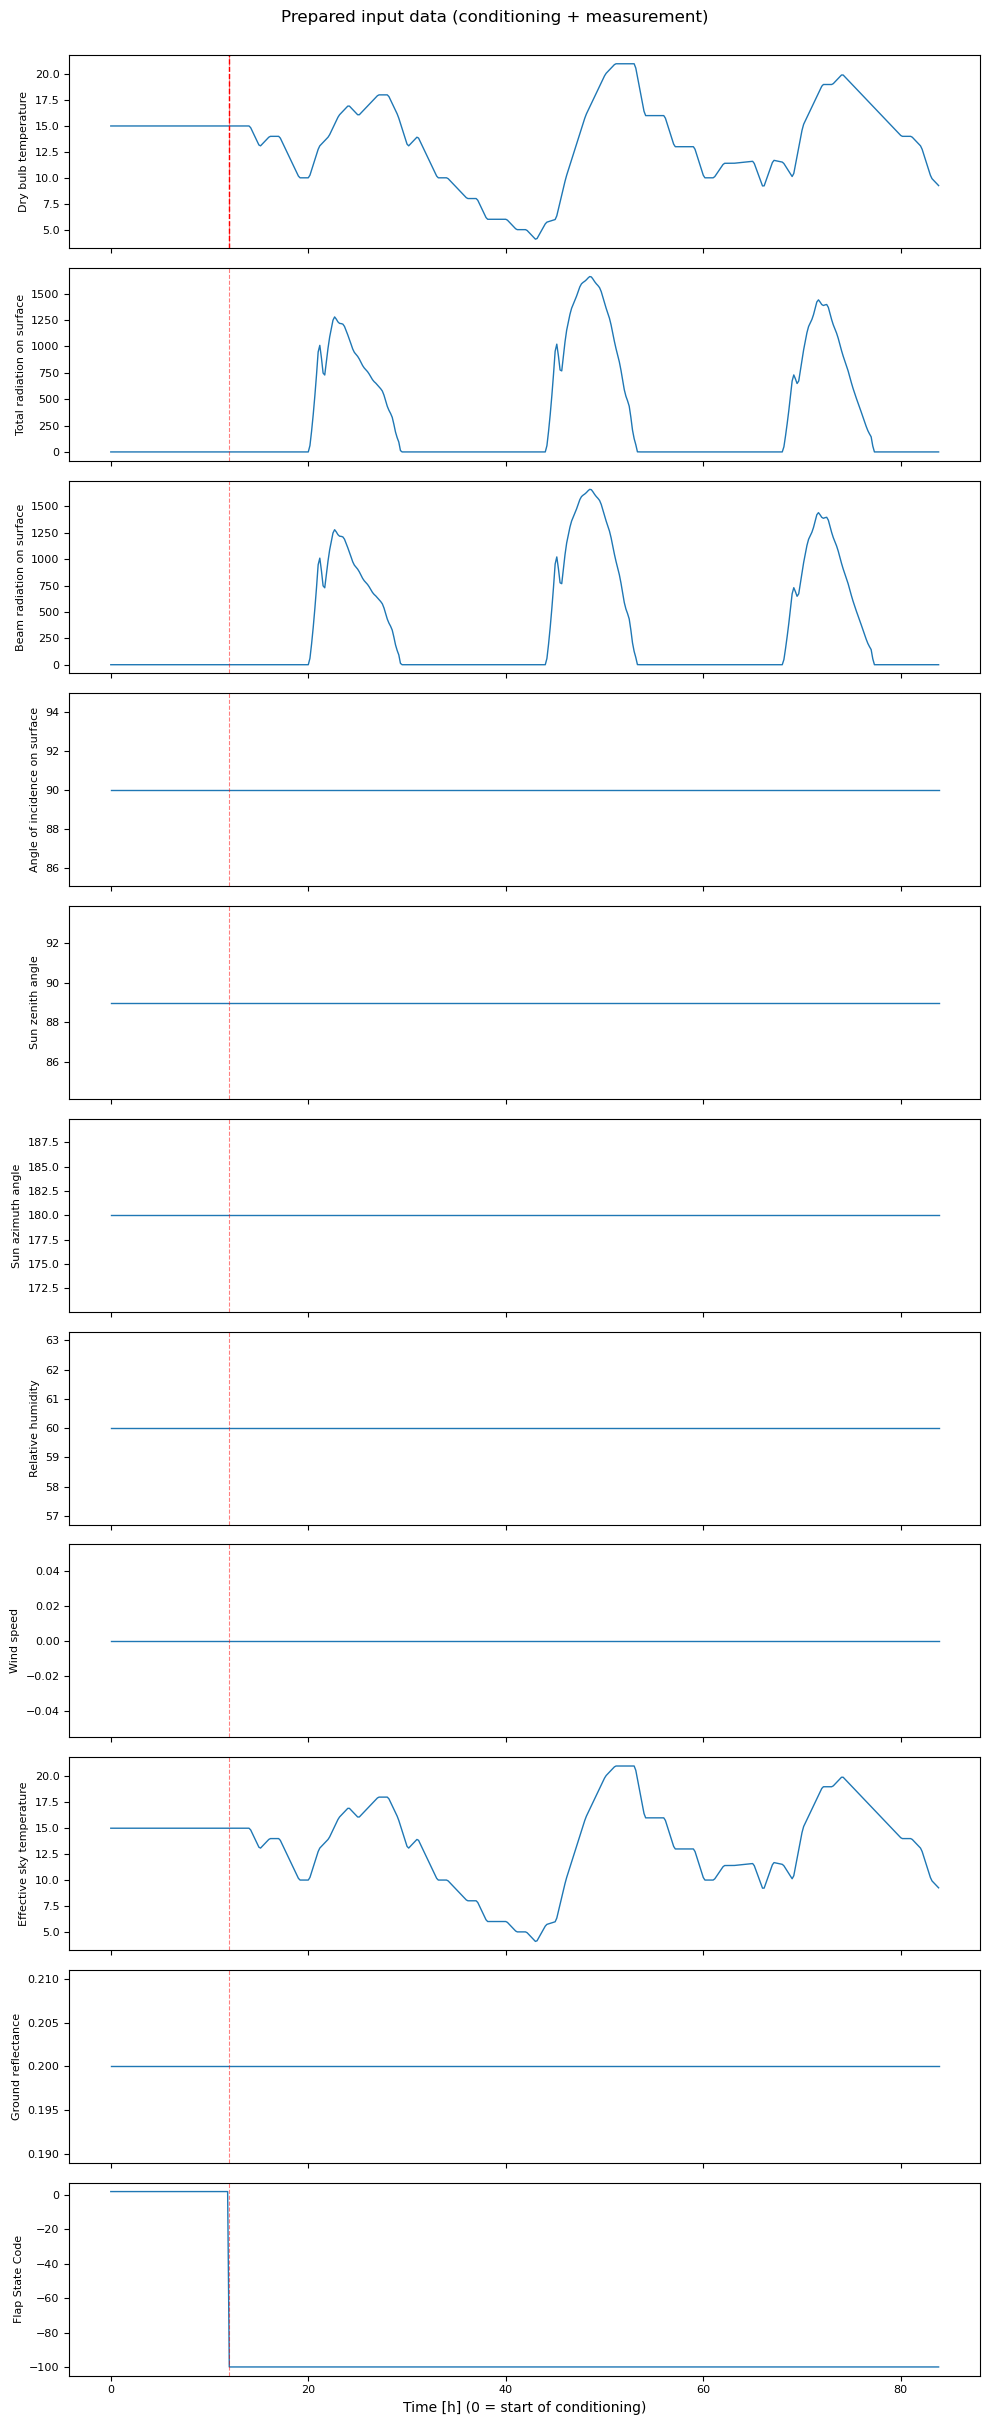

In [27]:
import matplotlib.pyplot as plt

# Build a time axis in hours (10-minute intervals)
prepared_data["time_h"] = prepared_data.index / 6  # 6 intervals per hour

cols_to_plot = [c for c in prepared_data.columns if c != "time_h"]

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(10, 2.2 * len(cols_to_plot)), sharex=True)

for ax, col in zip(axes, cols_to_plot):
    ax.plot(prepared_data["time_h"], prepared_data[col], linewidth=1)
    ax.set_ylabel(col, fontsize=8)
    ax.tick_params(labelsize=8)

# Mark the conditioning/measurement boundary
axes[0].axvline(intervals_for_conditioning / 6, color="red", linestyle="--", linewidth=1)
for ax in axes:
    ax.axvline(intervals_for_conditioning / 6, color="red", linestyle="--", linewidth=0.8, alpha=0.5)

axes[-1].set_xlabel("Time [h] (0 = start of conditioning)")
fig.suptitle("Prepared input data (conditioning + measurement)", y=1.0)
plt.tight_layout()
plt.show()